In [ ]:
import kagglehub
path = kagglehub.dataset_download("amankroot/crop-disease-detection-dataset")

100%|██████████| 812M/812M [00:48<00:00, 17.7MB/s]

Extracting files...


In [ ]:
import shutil
import os

source_path = path # This variable holds the extracted dataset path from kagglehub
ending = path.split("/")[-1]
target_directory = f'/content/datasets/{ending}'

# Create the target directory if it doesn't exist
os.makedirs(target_directory, exist_ok=True)

# Move the contents (not the folder itself) from source_path to target_directory
for item in os.listdir(source_path):
    s = os.path.join(source_path, item)
    d = os.path.join(target_directory, item)
    if os.path.isdir(s):
        shutil.copytree(s, d, dirs_exist_ok=True) # Use copytree for directories
    else:
        shutil.copy2(s, d) # Use copy2 for files to preserve metadata

print(f"Dataset moved from {source_path} to {target_directory}")

Dataset moved from /root/.cache/kagglehub/datasets/amankroot/crop-disease-detection-dataset/versions/2 to /content/datasets/2


In [ ]:
from pathlib import Path

root = Path("/content/datasets/final_dataset")
# root = Path("/content/datasets/resized_256")

total = 0

for cls in sorted(root.iterdir()):

    if cls.is_dir():

        count = len(list(cls.glob("*")))

        total += count

        print(f"{cls.name:<40} {count}")

print("\nTotal Images:", total)
print("Total Classes:", len(list(root.iterdir())))

Corn_Common_Rust                         1192
Corn_Gray_Leaf_Spot                      513
Corn_Healthy                             1161
Corn_Northern_Leaf_Blight                984
Pepper_Bacterial_Spot                    997
Pepper_Healthy                           1475
Potato_Early_Blight                      999
Potato_Healthy                           500
Potato_Late_Blight                       1000
Rice_Brown_Spot                          596
Rice_Healthy                             1443
Rice_Hispa                               500
Rice_Leaf_Blast                          932
Rice_Neck_Blast                          884
Sugarcane_Bacterial_Blight               500
Sugarcane_Healthy                        500
Sugarcane_Red_Rot                        500
Tomato_Bacterial_Spot                    2127
Tomato_Early_Blight                      1000
Tomato_Healthy                           1584
Tomato_Late_Blight                       1900
Tomato_Leaf_Mold                         952
T

# Cell 1: Install Dependencies

In [ ]:
!pip install -q timm grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 117.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


# Cell 2: Imports

In [ ]:
import os
import random
import numpy as np
import pandas as pd

from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn

from torchvision import transforms
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from torch.utils.data import WeightedRandomSampler

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

import timm

import matplotlib.pyplot as plt
import seaborn as sns

# Cell 3: Reproducibility

In [ ]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = False   # was True
torch.backends.cudnn.benchmark = True        # was False

# Cell 4: Dataset Path

In [ ]:
DATASET_DIR = "/content/datasets/final_dataset"

print("Classes:", len(os.listdir(DATASET_DIR)))

Classes: 39


# Cell 5: Build DataFrame

In [ ]:
data = []

classes = sorted(os.listdir(DATASET_DIR))

for cls in classes:

    cls_dir = os.path.join(DATASET_DIR, cls)

    for img in os.listdir(cls_dir):

        if img.lower().endswith(
            (".jpg",".jpeg",".png",".bmp")
        ):

            data.append([
                os.path.join(cls_dir, img),
                cls
            ])

df = pd.DataFrame(
    data,
    columns=["image_path","label"]
)

print(df.shape)
df.head()

(38349, 2)


,image_path,label
0,/content/datasets/final_dataset/Corn_Common_Ru...,Corn_Common_Rust
1,/content/datasets/final_dataset/Corn_Common_Ru...,Corn_Common_Rust
2,/content/datasets/final_dataset/Corn_Common_Ru...,Corn_Common_Rust
3,/content/datasets/final_dataset/Corn_Common_Ru...,Corn_Common_Rust
4,/content/datasets/final_dataset/Corn_Common_Ru...,Corn_Common_Rust


# Cell 6: Check Class Distribution

In [ ]:
df["label"].value_counts()

,count
label,
Tomato_Yellow_Leaf_Curl_Virus,3207
Tomato_Bacterial_Spot,2127
Tomato_Late_Blight,1900
Tomato_Septoria_Leaf_Spot,1771
Tomato_Spider_Mites,1674
Tomato_Healthy,1584
Pepper_Healthy,1475
Rice_Healthy,1443
Tomato_Target_Spot,1404


# Cell 7: Stratified Split

In [ ]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=SEED
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=SEED
)

print("Train:", len(train_df))
print("Val:", len(val_df))
print("Test:", len(test_df))

Train: 26844
Val: 5752
Test: 5753


# Cell 8: Label Mapping

In [ ]:
class_names = sorted(df["label"].unique())

label2idx = {
    cls:i
    for i, cls in enumerate(class_names)
}

idx2label = {
    i:cls
    for cls,i in label2idx.items()
}

NUM_CLASSES = len(class_names)

print(NUM_CLASSES)

39


# Cell 9: Transforms

In [ ]:
# EfficientNet-B4 input size = 380
# IMG_SIZE = 380
IMG_SIZE = 224

# Training augmentation:

train_transform = transforms.Compose([
    transforms.Resize((256, 256)),       # was 420
    transforms.RandomCrop((224, 224)),   # was 380
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [ ]:
# Validation/Test:
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),       # was 380
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Cell 10: Dataset Class

In [ ]:
class PlantDataset(Dataset):

    def __init__(
        self,
        dataframe,
        transform=None
    ):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        path = self.df.loc[idx, "image_path"]

        label = self.df.loc[idx, "label"]

        image = Image.open(path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        label = label2idx[label]

        return image, label

# Cell 11: Create Datasets

In [ ]:
train_dataset = PlantDataset(
    train_df,
    train_transform
)

val_dataset = PlantDataset(
    val_df,
    val_transform
)

test_dataset = PlantDataset(
    test_df,
    val_transform
)

# Cell 12: Weighted Sampler

Useful for imbalance.

In [ ]:
class_counts = train_df["label"].value_counts()

sample_weights = train_df["label"].map(
    lambda x: 1.0 / class_counts[x]
)

sample_weights = torch.DoubleTensor(
    sample_weights.values
)

sampler = WeightedRandomSampler(
    sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

# Cell 13: DataLoaders

In [ ]:
BATCH_SIZE = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=sampler,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

# Cell 14: Device

In [ ]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

device

device(type='cuda')

In [ ]:
from torch.amp import autocast, GradScaler

scaler = GradScaler("cuda")

# Cell 15: EfficientNet-B4

In [ ]:
model = timm.create_model(
    "efficientnet_b4",
    pretrained=True,
    num_classes=NUM_CLASSES
)

model = model.to(device)

NameError: name 'timm' is not defined

# Cell 16: Weighted CrossEntropy

In [ ]:
weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_df["label"]),
    y=train_df["label"]
)

weights = torch.tensor(
    weights,
    dtype=torch.float
).to(device)

criterion = nn.CrossEntropyLoss(
    weight=weights
)

# Cell 17: Optimizer

In [ ]:
# optimizer = torch.optim.AdamW(
#     model.parameters(),
#     lr=1e-4,
#     weight_decay=1e-4
# )
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-4,
    weight_decay=1e-4
)

# Cell 18: Scheduler

In [ ]:
# scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
#     optimizer,
#     T_max=20
# )
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=25
)

# Cell 19: Training Function

In [ ]:
# def train_one_epoch(model, loader):

#     model.train()

#     running_loss = 0
#     correct = 0
#     total = 0

#     for images, labels in tqdm(loader):

#         images = images.to(device)
#         labels = labels.to(device)

#         optimizer.zero_grad()

#         outputs = model(images)

#         loss = criterion(
#             outputs,
#             labels
#         )

#         loss.backward()

#         optimizer.step()

#         running_loss += loss.item()

#         preds = outputs.argmax(1)

#         correct += (
#             preds == labels
#         ).sum().item()

#         total += labels.size(0)

#     return (
#         running_loss / len(loader),
#         100 * correct / total
#     )

def train_one_epoch(model, loader):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in tqdm(loader):

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with autocast(device_type="cuda"):

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

        scaler.scale(loss).backward()

        scaler.step(optimizer)

        scaler.update()

        running_loss += loss.item()

        preds = outputs.argmax(1)

        correct += (
            preds == labels
        ).sum().item()

        total += labels.size(0)

    return (
        running_loss / len(loader),
        100 * correct / total
    )

# Cell 20: Validation Function

In [ ]:
# def evaluate(model, loader):

#     model.eval()

#     correct = 0
#     total = 0

#     with torch.no_grad():

#         for images, labels in loader:

#             images = images.to(device)
#             labels = labels.to(device)

#             outputs = model(images)

#             preds = outputs.argmax(1)

#             correct += (
#                 preds == labels
#             ).sum().item()

#             total += labels.size(0)

#     return 100 * correct / total

def evaluate(model, loader):

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            with autocast(device_type="cuda"):

                outputs = model(images)

            preds = outputs.argmax(1)

            correct += (
                preds == labels
            ).sum().item()

            total += labels.size(0)

    return 100 * correct / total

# Cell 21: Training Loop

In [ ]:
EPOCHS = 10
PATIENCE = 3  # stop if val acc doesn't improve for 3 epochs
best_acc = 0

In [ ]:
patience_counter = 0
best_val = 0

for epoch in range(EPOCHS):

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader
    )

    val_acc = evaluate(
        model,
        val_loader
    )

    scheduler.step()

    print(
        f"Epoch {epoch+1}/{EPOCHS}"
        f" | Loss={train_loss:.4f}"
        f" | Train={train_acc:.2f}"
        f" | Val={val_acc:.2f}"
    )

    if val_acc > best_val:
        best_val = val_acc
        patience_counter = 0
        torch.save(model.state_dict(), "best_model.pth")
        print("Model Saved")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"Early stopping at epoch {epoch+1}")
            break

100%|██████████| 420/420 [03:13<00:00,  2.18it/s]


Epoch 1/10 | Loss=0.5970 | Train=79.56 | Val=87.45
Model Saved


100%|██████████| 420/420 [02:52<00:00,  2.43it/s]


Epoch 2/10 | Loss=0.1011 | Train=95.41 | Val=93.13
Model Saved


100%|██████████| 420/420 [02:52<00:00,  2.43it/s]


...

Epoch 8/10 | Loss=0.0202 | Train=99.14 | Val=96.66


100%|██████████| 420/420 [02:55<00:00,  2.40it/s]


Epoch 9/10 | Loss=0.0177 | Train=99.19 | Val=96.45


100%|██████████| 420/420 [02:54<00:00,  2.40it/s]


Epoch 10/10 | Loss=0.0149 | Train=99.37 | Val=96.59
Early stopping at epoch 10


# Cell 22: Load Best Model

In [ ]:
model.load_state_dict(
    torch.load(
        "best_model.pth",
        map_location=device
    )
)

NameError: name 'model' is not defined

# Cell 23: Test Accuracy

In [ ]:
test_acc = evaluate(
    model,
    test_loader
)

print("Test Accuracy:", test_acc)

Test Accuracy: 97.49695810881279


# Cell 24: Classification Report

In [ ]:
y_true = []
y_pred = []

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        preds = outputs.argmax(1)

        y_true.extend(labels.numpy())
        y_pred.extend(
            preds.cpu().numpy()
        )

In [ ]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

                               precision    recall  f1-score   support

             Corn_Common_Rust       0.99      1.00      1.00       179
          Corn_Gray_Leaf_Spot       0.91      0.97      0.94        77
                 Corn_Healthy       1.00      1.00      1.00       174
    Corn_Northern_Leaf_Blight       0.99      0.95      0.97       147
        Pepper_Bacterial_Spot       0.99      1.00      1.00       149
               Pepper_Healthy       1.00      1.00      1.00       222
          Potato_Early_Blight       1.00      0.99      1.00       150
               Potato_Healthy       1.00      1.00      1.00        75
           Potato_Late_Blight       1.00      0.99      0.99       150
              Rice_Brown_Spot       0.84      0.83      0.84        89
                 Rice_Healthy       0.90      0.91      0.91       217
                   Rice_Hispa       0.95      1.00      0.97        75
              Rice_Leaf_Blast       0.87      0.83      0.85       140
     

# Cell 25: Confusion Matrix

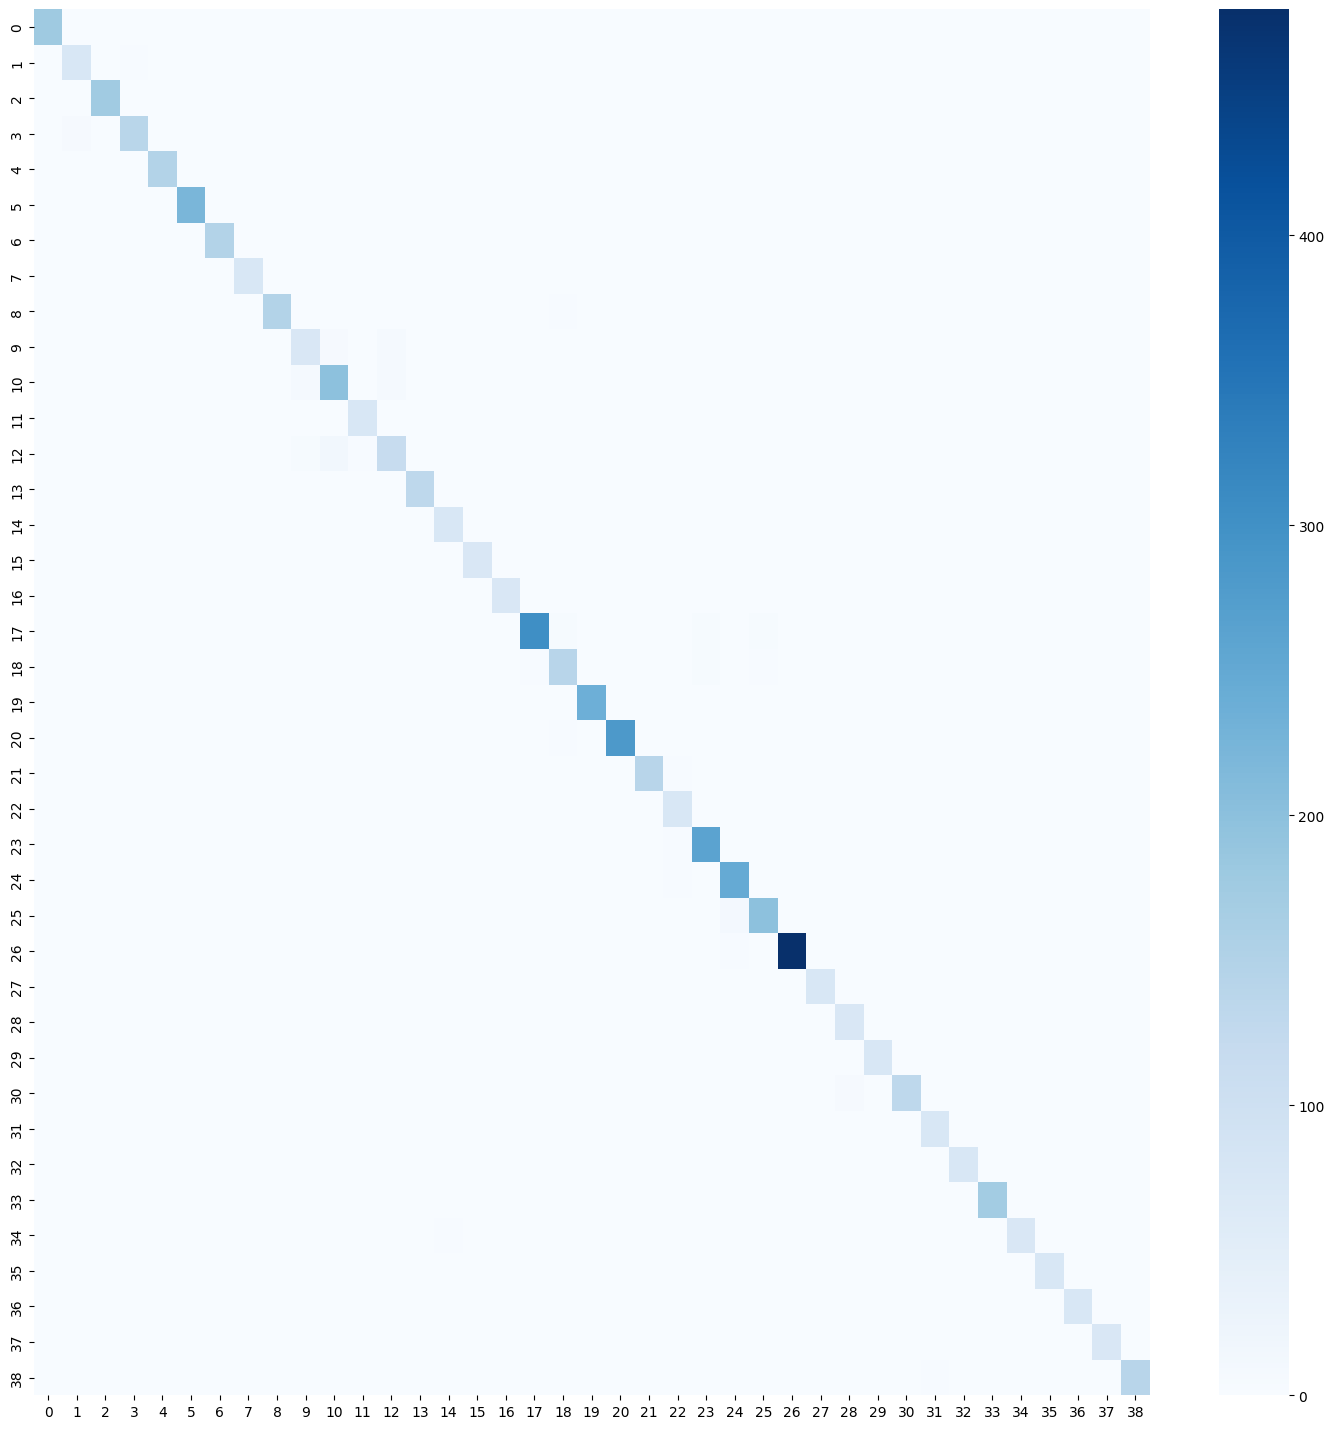

In [ ]:
cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(18,18))

sns.heatmap(
    cm,
    cmap="Blues"
)

plt.show()

# Cell 26: Grad-CAM

In [ ]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

# Cell 27: Find EfficientNet-B4 Last Convolution Layer

In [ ]:
target_layers = [
    model.blocks[-1]
]

# Cell 28: Generate Grad-CAM

Replace with a test image path.

In [ ]:
# IMAGE_PATH = test_df.iloc[0]["image_path"]
# IMAGE_PATH = "/content/datasets/final_dataset/Rice_Brown_Spot/Rice_BrownSpot_IMG_20190420_190644.jpg"
# IMAGE_PATH = "/content/datasets/final_dataset/Rice_Brown_Spot/Rice_BrownSpot_IMG_20190420_190910.jpg"
IMAGE_PATH = "/content/Corn___Northern_Leaf_Blight_image_(102).jpg"

In [ ]:
img = Image.open(
    IMAGE_PATH
).convert("RGB")

rgb_img = np.array(
    img.resize((224,224))
) / 255.0

In [ ]:
input_tensor = val_transform(img)

input_tensor = input_tensor.unsqueeze(0).to(device)

In [ ]:
cam = GradCAM(
    model=model,
    target_layers=target_layers
)

grayscale_cam = cam(
    input_tensor=input_tensor
)[0]

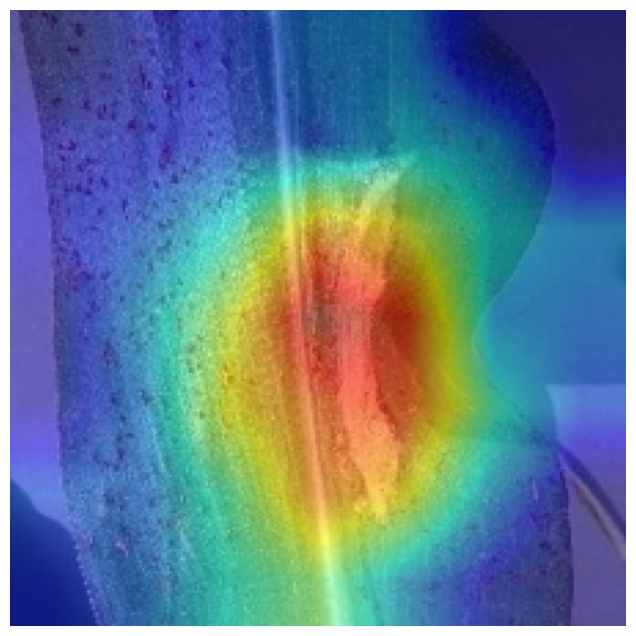

In [ ]:
visualization = show_cam_on_image(
    rgb_img,
    grayscale_cam,
    use_rgb=True
)

plt.figure(figsize=(8,8))
plt.imshow(visualization)
plt.axis("off")
plt.show()

In [ ]:
!pip install -q onnx onnxscript onnxruntime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 47.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 714.8/714.8 kB 30.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 31.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.8/166.8 kB 5.2 MB/s eta 0:00:00


In [ ]:
import timm
import torch

# Define NUM_CLASSES for model initialization
NUM_CLASSES = 39

# Re-instantiate the model and load its weights
# This ensures 'model' is a torch.nn.Module instance before ONNX export
model = timm.create_model(
    "efficientnet_b4",
    pretrained=True,
    num_classes=NUM_CLASSES
)

model = model.to(device)

model.load_state_dict(
    torch.load(
        "best_model.pth",
        map_location=device
    )
)

# Set model to evaluation mode for export
model.eval()

dummy = torch.randn(1,3,224,224).to(device)

torch.onnx.export(
    model,
    dummy,
    "plant_disease.onnx",
    opset_version=18,
    input_names=["input"],
    output_names=["output"],
    dynamic_shapes={
        "input": {0: "batch"} # Corrected from 'x' to 'input'
    },
    do_constant_folding=True,
    training=torch.onnx.TrainingMode.EVAL,
    export_params=True,
    keep_initializers_as_inputs=False,
)

print("plant_disease.onnx re-exported successfully with corrected dynamic_shapes!")

[torch.onnx] Obtain model graph for `EfficientNet([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `EfficientNet([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅


ONNXProgram(
    model=
        <
            ir_version=10,
            opset_imports={'': 18},
            producer_name='pytorch',
            producer_version='2.11.0+cu128',
            domain=None,
            model_version=None,
        >
        graph(
            name=main_graph,
            inputs=(
                %"input"<FLOAT,[batch,3,224,224]>
            ),
            outputs=(
                %"output"<FLOAT,[batch,39]>
            ),
            initializers=(
                %"conv_stem.weight"<FLOAT,[48,3,3,3]>{Tensor(...)},
                %"blocks.0.0.conv_dw.weight"<FLOAT,[48,1,3,3]>{Tensor(...)},
                %"blocks.0.0.se.conv_reduce.weight"<FLOAT,[12,48,1,1]>{TorchTensor(...)},
                %"blocks.0.0.se.conv_reduce.bias"<FLOAT,[12]>{TorchTensor(...)},
                %"blocks.0.0.se.conv_expand.weight"<FLOAT,[48,12,1,1]>{TorchTensor(...)},
                %"blocks.0.0.se.conv_expand.bias"<FLOAT,[48]>{TorchTensor(...)},
                %"blocks.0.0.

In [ ]:
import os

print(os.path.exists("plant_disease.onnx"))
print(os.path.getsize("plant_disease.onnx"))

True
1028914


In [ ]:
import onnx

model = onnx.load("plant_disease.onnx")
onnx.checker.check_model(model)

print("Valid ONNX model")
print("Opset:", model.opset_import[0].version)

Valid ONNX model
Opset: 18


In [ ]:
  # torch.onnx.export(
#     model,
#     dummy,
#     "plant_disease.onnx",
#     opset_version=18, # use 17 as 18 is not supported for TensorLite i.e., will not work in edge devices!
#     input_names=["input"],
#     output_names=["output"]
# )

In [ ]:
# In Colab / your FastAPI backend
from inference import PlantDiseaseClassifier

ModuleNotFoundError: No module named 'inference'

In [ ]:


clf = PlantDiseaseClassifier("plant_disease.onnx")
result = clf.predict("/content/datasets/final_dataset/Corn_Gray_Leaf_Spot/Corn___Gray_Leaf_Spot_image_(102).jpg")
print(result)

/usr/local/lib/python3.12/dist-packages/onnxruntime/capi/onnxruntime_inference_collection.py:149: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


{'disease': 'Corn_Gray_Leaf_Spot', 'confidence_pct': 99.66, 'severity': 'Severe', 'is_healthy': False, 'top3': [{'disease': 'Corn_Gray_Leaf_Spot', 'confidence': 99.66}, {'disease': 'Corn_Common_Rust', 'confidence': 0.16}, {'disease': 'Rice_Neck_Blast', 'confidence': 0.04}]}


In [ ]:
import timm

# NUM_CLASSES and device are defined in previous cells
# Re-instantiate the model as it might not be defined due to previous errors
model = timm.create_model(
    "efficientnet_b4",
    pretrained=True,
    num_classes=39
)

model = model.to(device)

model.load_state_dict(
    torch.load(
        "best_model.pth",
        map_location=device
    )
)

print("Model loaded successfully!")

Model loaded successfully!


In [ ]:
from onnxruntime.quantization import quantize_dynamic, QuantType
import onnx
import os
import torch
import timm

# Define NUM_CLASSES and device (assuming they are already defined in kernel state)
# NUM_CLASSES = 39 # Uncomment if NUM_CLASSES is not in scope
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # Uncomment if device is not in scope

# --- Re-export plant_disease.onnx to ensure it exists for quantization ---
# This replicates the original content of cell ed8C4VaK5_21 before it was modified for feature export
model = timm.create_model(
    "efficientnet_b4",
    pretrained=True,
    num_classes=NUM_CLASSES
)
model = model.to(device)
model.load_state_dict(
    torch.load(
        "best_model.pth",
        map_location=device
    )
)
model.eval()
dummy = torch.randn(1,3,224,224).to(device)

torch.onnx.export(
    model,
    dummy,
    "plant_disease.onnx", # This will create the required file
    opset_version=18,
    input_names=["input"],
    output_names=["output"],
    dynamic_shapes={
        "input": {0: "batch"}
    },
    do_constant_folding=True,
    training=torch.onnx.TrainingMode.EVAL,
    export_params=True,
    keep_initializers_as_inputs=False,
)
print("plant_disease.onnx re-exported successfully!")
# -----------------------------------------------------------------------

# Now, proceed with quantization of the re-exported model
model_path = "plant_disease.onnx"

# Load the ONNX model
model_to_quantize = onnx.load(model_path)

# Perform dynamic quantization
quantize_dynamic(
    model_input=model_to_quantize, # Pass the loaded model object
    model_output="plant_disease_int8.onnx",
    weight_type=QuantType.QInt8
)

print("Quantization successful!")

NameError: name 'NUM_CLASSES' is not defined

In [ ]:
from onnxruntime.quantization import quantize_dynamic, QuantType

quantize_dynamic(
    model_input="plant_disease.onnx",
    model_output="plant_disease_int8.onnx",
    weight_type=QuantType.QInt8,
    per_channel=True,
    reduce_range=False
)

InferenceError: [ShapeInferenceError] Inferred shape and existing shape differ in dimension 0: (1792) vs (39)

In [ ]:
!pwd

/content
